## Import Libraries

In [88]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Loading Image and Video

In [89]:
img = cv2.imread('assignment_2_materials/cv_cover.jpg')
img.shape


(440, 350, 3)

In [90]:
def play_video(filename):
    vid = cv2.VideoCapture(filename)
    if not vid.isOpened():
        print("Error: Could not open video file.")
        exit()

    while True:
        ret, frame = vid.read()

        if not ret: #if frame was not returned successfully
            break   

        cv2.imshow("Video", frame)
        # press Q to quit
        if cv2.waitKey(25) & 0xFF == ord('q'):
            break
    vid.release()
    cv2.destroyAllWindows()

In [91]:
play_video('assignment_2_materials/book.mov')

## Getting First frame

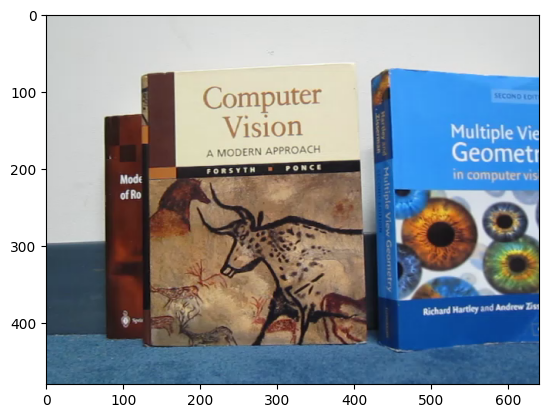

In [92]:
cap = cv2.VideoCapture("assignment_2_materials/book.mov")
cap.set(cv2.CAP_PROP_POS_FRAMES, 0) #gets first frame
res, frame = cap.read()
frame_RGB = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_RGB)


## Using SIFT to get keypoints

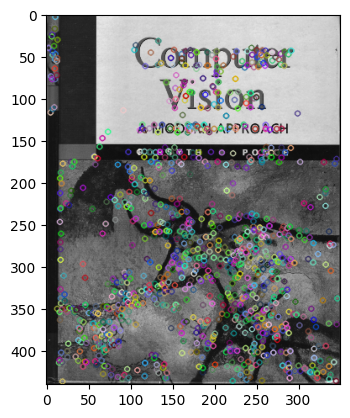

In [93]:
frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()
img_kp, des_img = sift.detectAndCompute(img_gray,None) # returns keypoints and descriptors array
frame_kp, des_frame = sift.detectAndCompute(frame_gray,None)
img_withPoints = img.copy()
cv2.drawKeypoints(img_gray,img_kp,img_withPoints)
plt.imshow(img_withPoints)

## Brute Force Matcher to get best 50 matches

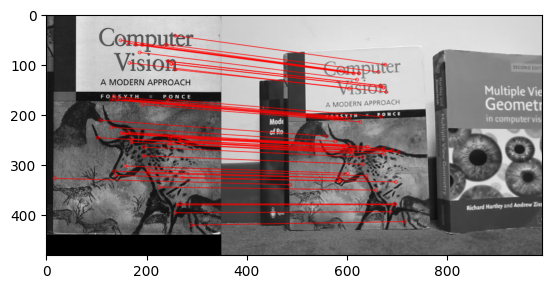

In [94]:
bf = cv2.BFMatcher() # each descriptor compared against all descriptors
matches = bf.knnMatch(des_img,des_frame,k=2)
good_matches = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good_matches.append([m])
best_50 = sorted(good_matches, key=lambda x: x[0].distance)[:50] #sort by shortest distance
matched_img = cv2.drawMatchesKnn(img_gray,img_kp,frame_gray,frame_kp,best_50,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS, matchColor=(255,0,0))
 
plt.imshow(matched_img)

## Homography matrix function

In [95]:
def compute_homography_matrix(src_points, dst_points):
    A = []
    number_of_points = len(src_points)
    for i in range(number_of_points):
        x_1, y_1 = src_points[i][0], src_points[i][1] # x, y
        x_2, y_2 = dst_points[i][0], dst_points[i][1] # x' and y'
        A.append([x_1, y_1, 1, 0, 0, 0, -x_1*x_2, -y_1*x_2, -x_2]) # x'(h_7x + h_8y + h_9) = (h_1x + h_2y + h_3)
        A.append([0, 0, 0, x_1, y_1, 1, -x_1*y_2, -y_1*y_2, -y_2]) # y'(h_7x + h_8y + h_9) = (h_4x + h_5y + h_6)

    A = np.array(A)
    _, _, V = np.linalg.svd(A) # to solve Ah=0 and minimize reprojection error
    H = np.reshape(V[-1], (3, 3)) # reshape to 3x3
    H = (1 / H.item(8)) * H # dividing by the scale factor to make H(3x3) = 1
    return H

## Function to draw 2 mapped image points

In [96]:
def draw_mappedPoints(pts, H):
    mapped_pts = cv2.perspectiveTransform(pts, H)
    img_copy = img.copy()
    frame_copy = frame_RGB.copy()
    for pt in pts:
        cv2.circle(img_copy, tuple(pt[0].astype(int)), 5, (255, 0, 0), -1)

    for pt in mapped_pts:
        cv2.circle(frame_copy, tuple(pt[0].astype(int)), 5, (255, 0, 0), -1)

    plt.figure(figsize=(16,8))
    plt.subplot(1, 2, 1)
    plt.imshow(img_copy)
    plt.subplot(1, 2, 2)
    plt.imshow(frame_copy)

## Mapping some random points

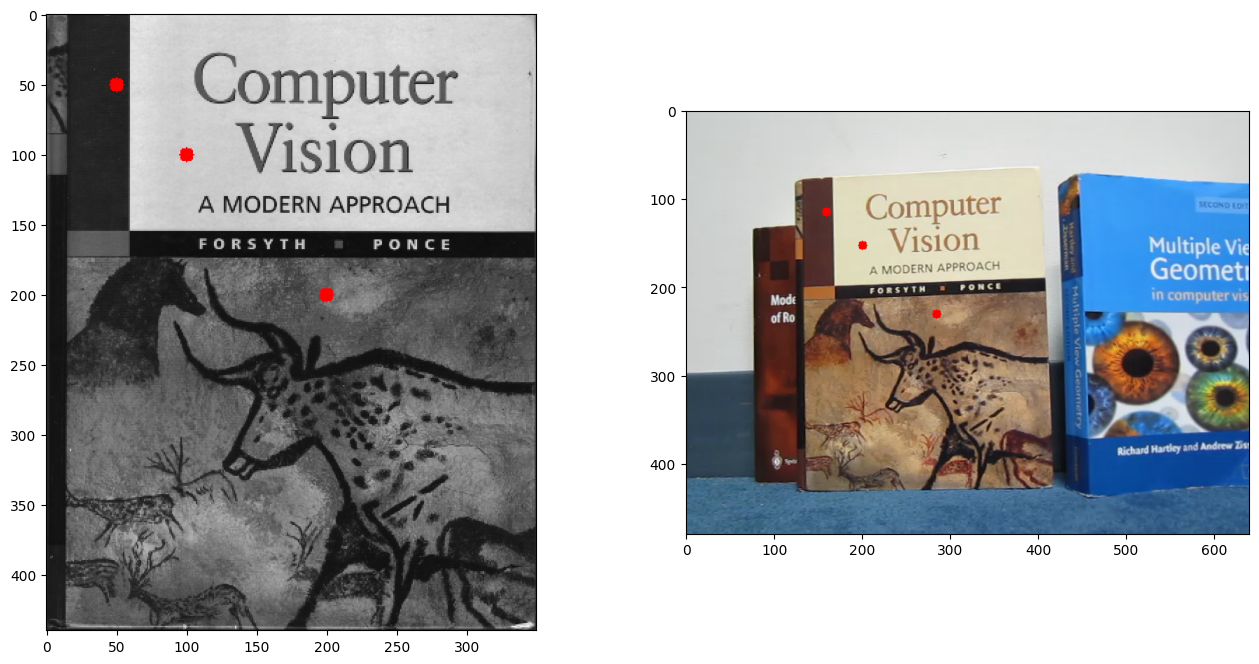

In [ ]:
src_points = np.float32([img_kp[m[0].queryIdx].pt for m in best_50]).reshape(-1, 2) #extracting coordinates of the keypoints from the good matches and reshaping to 2D array
dst_points = np.float32([frame_kp[m[0].trainIdx].pt for m in best_50]).reshape(-1, 2)

H = compute_homography_matrix(src_points, dst_points)
test_pts = np.float32([[50, 50], [100, 100], [200, 200]]).reshape(-1, 1, 2) # reshape to 3D array for perspectiveTransform function
draw_mappedPoints(test_pts,H)

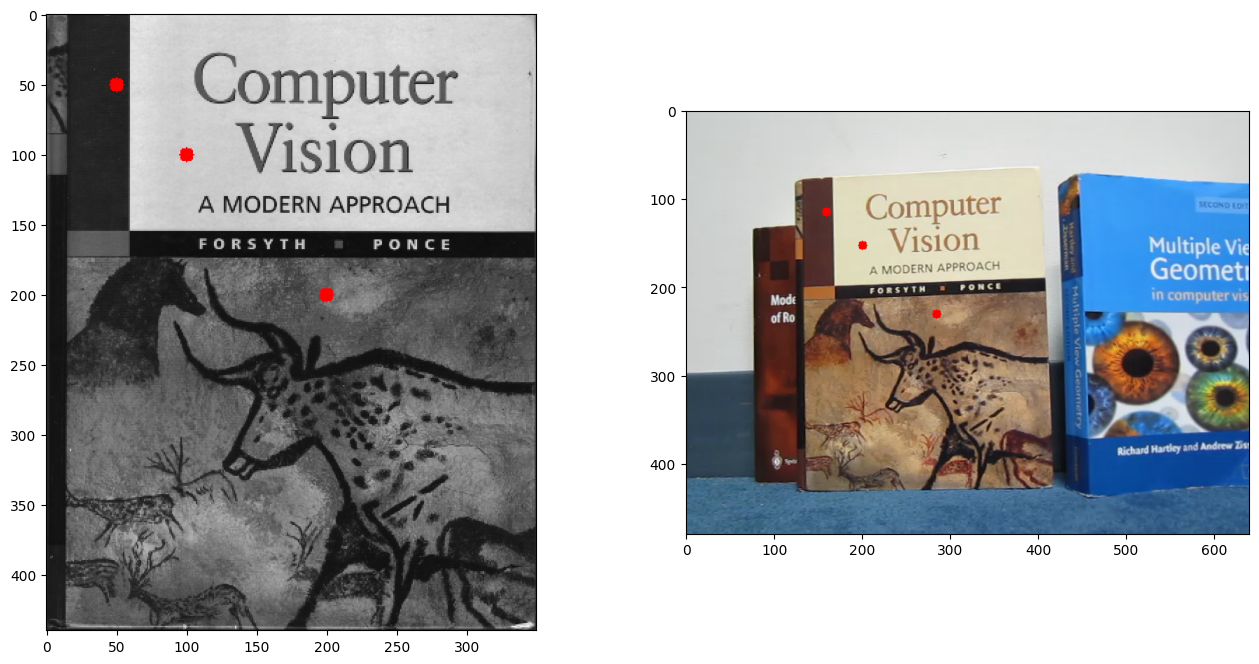

In [98]:
H_builtIN,_ = cv2.findHomography(src_points, dst_points) # same result with built in function
draw_mappedPoints(test_pts,H_builtIN)

## Detecting corners in video frame

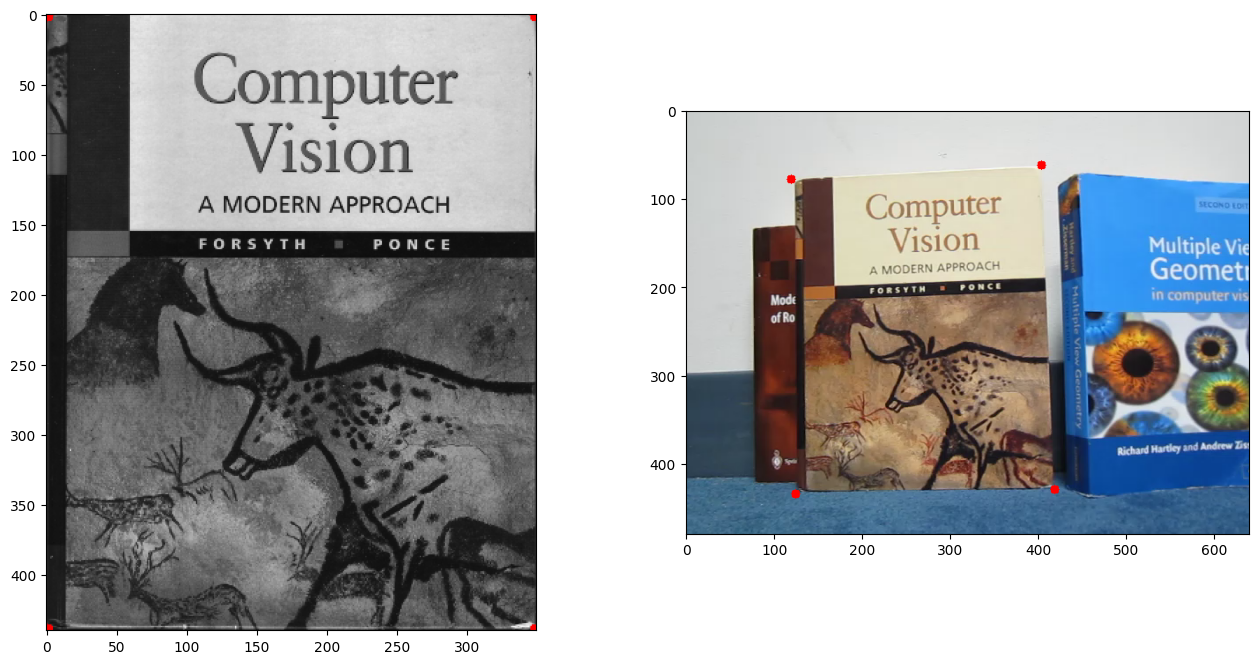

In [99]:
h,w = img_gray.shape
corner_pts = np.float32([[0,0], [0,h], [w,h], [w,0]]).reshape(-1, 1, 2)
draw_mappedPoints(corner_pts,H)